In [1]:
import torch

# Check if CUDA (GPU support) is available
gpu_available = torch.cuda.is_available()
print(f"Is GPU available? {gpu_available}")

if gpu_available:
    # Get the name of the GPU device
    device_name = torch.cuda.get_device_name(0)
    print(f"Connected GPU: {device_name}")

    # Display current device and capability
    print(f"Active CUDA Device index: {torch.cuda.current_device()}")
    print(f"Device capability: {torch.cuda.get_device_capability(0)}")
else:
    print("No GPU detected. Please go to Runtime -> Change runtime type and select 'T4 GPU'.")


Is GPU available? True
Connected GPU: Tesla T4
Active CUDA Device index: 0
Device capability: (7, 5)


In [2]:
!pip install -q kagglehub tensorflow scikit-learn seaborn pandas matplotlib pillow


In [3]:
import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import kagglehub
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:

PROJECT_ROOT = Path.cwd()

DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = PROJECT_ROOT / "classification_outputs"
MODEL_DIR = OUTPUT_DIR / "models"
PLOT_DIR = OUTPUT_DIR / "plots"
REPORT_DIR = OUTPUT_DIR / "reports"
LOG_DIR = OUTPUT_DIR / "logs"

for directory in [DATASET_DIR, OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR)
print("Output directory:", OUTPUT_DIR)


Project root: /content
Dataset directory: /content/dataset
Output directory: /content/classification_outputs


In [5]:
kaggle_path = kagglehub.dataset_download(
    "anasmohammedtahir/covidqu"
)

print("Original KaggleHub dataset location:")
print(kaggle_path)

kaggle_path = Path(kaggle_path)


100%|██████████| 1.15G/1.15G [01:04<00:00, 19.1MB/s]

Extracting files...


Original KaggleHub dataset location:
/root/.cache/kagglehub/datasets/anasmohammedtahir/covidqu/versions/7


In [6]:
if DATASET_DIR.exists():
    for item in DATASET_DIR.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

DATASET_DIR.mkdir(parents=True, exist_ok=True)


In [7]:
source_items = list(kaggle_path.iterdir()) if kaggle_path.is_dir() else []

if len(source_items) == 1 and source_items[0].is_dir():
    source_root = source_items[0]
else:
    source_root = kaggle_path

for item in source_root.iterdir():
    destination = DATASET_DIR / item.name
    if item.is_dir():
        shutil.copytree(item, destination)
    else:
        shutil.copy2(item, destination)

print("\nDataset copied to:")
print(DATASET_DIR.resolve())



Dataset copied to:
/content/dataset


In [8]:
for path in sorted(DATASET_DIR.rglob("*")):
    if path.is_dir():
        print(path.relative_to(DATASET_DIR))


Infection Segmentation Data
Infection Segmentation Data/Infection Segmentation Data
Infection Segmentation Data/Infection Segmentation Data/Test
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/images
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/infection masks
Infection Segmentation Data/Infection Segmentation Data/Test/COVID-19/lung masks
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/images
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/infection masks
Infection Segmentation Data/Infection Segmentation Data/Test/Non-COVID/lung masks
Infection Segmentation Data/Infection Segmentation Data/Test/Normal
Infection Segmentation Data/Infection Segmentation Data/Test/Normal/images
Infection Segmentation Data/Infection Segmentation Data/Test/Normal/infection ma

In [9]:

DELETE_UNUSED_DATA = True

if DELETE_UNUSED_DATA:
    folders_to_delete = [
        DATASET_DIR / "Infection Segmentation Data",
    ]

    for folder in folders_to_delete:
        if folder.exists():
            print("Deleting unused folder:", folder)
            shutil.rmtree(folder)
        else:
            print("Folder not found; nothing to delete:", folder)
else:
    print("No downloaded dataset folders were deleted.")

print("Cleanup complete.")


Deleting unused folder: /content/dataset/Infection Segmentation Data
Cleanup complete.


In [10]:

def find_split_dir(root, split_name):
    matches = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() == split_name.lower()
    ]
    if not matches:
        raise FileNotFoundError(f"Could not find {split_name} directory under {root}")
    # Prefer the deepest match that contains at least one expected class folder.
    expected_names = {"COVID-19", "Non-COVID", "Normal"}
    ranked = []
    for p in matches:
        child_names = {x.name for x in p.iterdir() if x.is_dir()}
        score = len(child_names & expected_names)
        ranked.append((score, len(p.parts), p))
    ranked.sort(reverse=True, key=lambda x: (x[0], x[1]))
    return ranked[0][2]


In [11]:
import shutil
from pathlib import Path

# Define the split directories we want to inspect
split_dirs = [
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train'),
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val'),
    Path('/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test')
]

# Iterate through each split and delete any folder named 'lung masks'
for split in split_dirs:
    if split.exists():
        # Find all subdirectories within this split matching 'lung masks' (case-insensitive)
        for folder in split.rglob("*"):
            if folder.is_dir() and folder.name.lower() == "lung masks":
                print(f"Deleting folder: {folder}")
                shutil.rmtree(folder)
    else:
        print(f"Directory not found: {split}")

Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/COVID-19/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/COVID-19/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/Non-COVID/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/COVID-19/lung masks
Deleting folder: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/lung masks


In [12]:

TRAIN_DIR = '/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train'
VAL_DIR = '/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val'
TEST_DIR = '/content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test'

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:  ", VAL_DIR)
print("TEST_DIR: ", TEST_DIR)


TRAIN_DIR: /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Train
VAL_DIR:   /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Val
TEST_DIR:  /content/dataset/Lung Segmentation Data/Lung Segmentation Data/Test


In [14]:
from pathlib import Path

CLASS_NAMES = ["COVID-19", "Non-COVID", "Normal"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def collect_class_counts(split_dir):
    # Ensure split_dir is a Path object
    split_dir = Path(split_dir)
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = split_dir / class_name / "images"
        if not class_dir.exists():
            # Fallback in case images are directly inside the class directory.
            class_dir = split_dir / class_name

        if not class_dir.exists():
            raise FileNotFoundError(
                f"Missing class directory for '{class_name}' in {split_dir}"
            )

        image_files = [
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        ]
        counts[class_name] = len(image_files)
    return counts

split_counts = pd.DataFrame({
    "Train": collect_class_counts(TRAIN_DIR),
    "Validation": collect_class_counts(VAL_DIR),
    "Test": collect_class_counts(TEST_DIR),
}).T

display(split_counts)
print("\nTotal images by split:")
print(split_counts.sum(axis=1))

,COVID-19,Non-COVID,Normal
Train,7658,7208,6849
Validation,1903,1802,1712
Test,2395,2253,2140



Total images by split:
Train         21715
Validation     5417
Test           6788
dtype: int64


In [15]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    color_mode="rgb",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class names:", train_ds.class_names)


Found 21715 files belonging to 3 classes.
Found 5417 files belonging to 3 classes.
Found 6788 files belonging to 3 classes.
Class names: ['COVID-19', 'Non-COVID', 'Normal']


In [16]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(height_factor=0.10, width_factor=0.10),
        layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
        layers.RandomContrast(0.10),
    ],
    name="train_augmentation",
)

def normalize_only(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

def augment_and_normalize(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    images = data_augmentation(images, training=True)
    return images, labels

train_ds = (
    train_ds
    .map(augment_and_normalize, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(normalize_only, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(normalize_only, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Training augmentation + normalization configured.")
print("Validation/test normalization: image / 255.0")


Training augmentation + normalization configured.
Validation/test normalization: image / 255.0


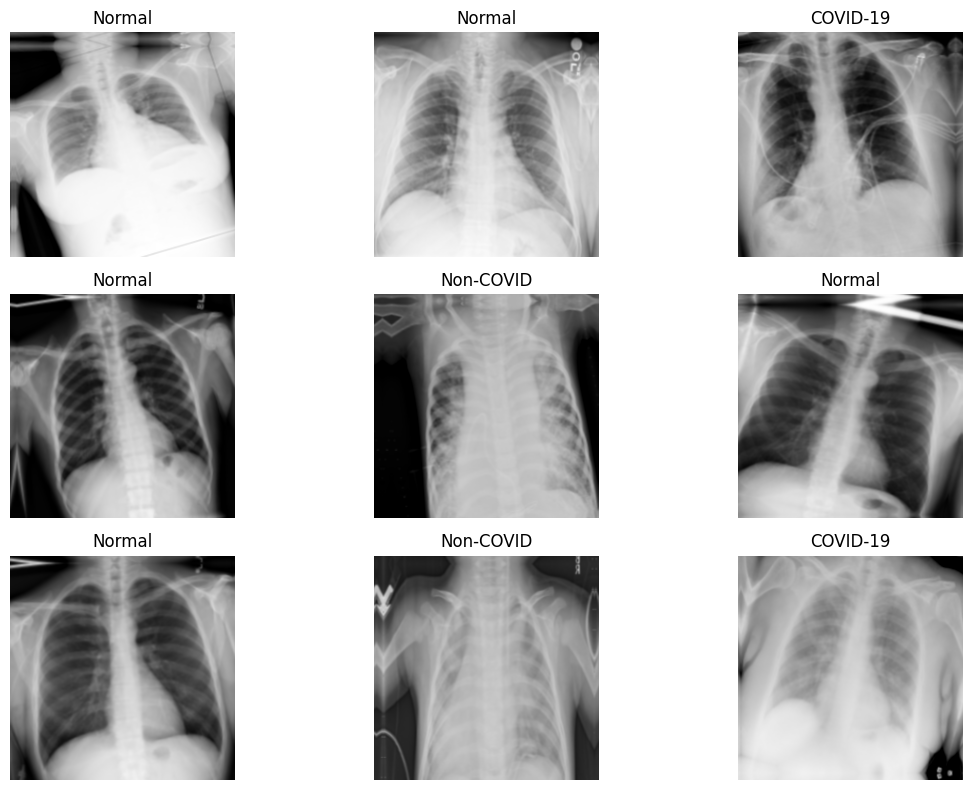

In [17]:
sample_images, sample_labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(min(9, len(sample_images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title(CLASS_NAMES[int(sample_labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.savefig(PLOT_DIR / "training_augmentation_examples.png", dpi=200, bbox_inches="tight")
plt.show()


In [18]:
base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
)

base_model.trainable = False

# Unfreeze only the last DenseNet dense block.
for layer in base_model.layers:
    if layer.name.startswith("conv5_block"):
        layer.trainable = True

inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="xray")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.35, name="dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classifier")(x)

model = keras.Model(inputs, outputs, name="DenseNet121_COVIDQU_Ex")

# The classifier is trainable by default.
trainable_layers = [layer.name for layer in model.layers if layer.trainable]

print("Trainable model layers:")
for name in trainable_layers:
    print(" -", name)

print("\nTotal parameters:", model.count_params())


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Trainable model layers:
 - xray
 - global_average_pooling
 - dropout
 - classifier

Total parameters: 7040579


In [19]:
INITIAL_LR = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = keras.optimizers.AdamW(
    learning_rate=INITIAL_LR,
    weight_decay=WEIGHT_DECAY,
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "DenseNet121_COVIDQU_Ex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xray (InputLayer)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 2,161,155 (8.24 MB)

 Non-trainable params: 4,879,424 (18.61 MB)

In [20]:
BEST_MODEL_PATH = MODEL_DIR / "best_densenet121_covidqu.keras"
CSV_LOG_PATH = LOG_DIR / "training_log.csv"

callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    CSVLogger(
        str(CSV_LOG_PATH),
        append=False,
    ),
]

print("Callbacks configured:")
for cb in callbacks:
    print(" -", cb.__class__.__name__)


Callbacks configured:
 - ModelCheckpoint
 - EarlyStopping
 - ReduceLROnPlateau
 - CSVLogger


In [21]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

print("Training complete.")


Epoch 1/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6995 - loss: 0.6955
Epoch 1: val_accuracy improved from None to 0.85859, saving model to /content/classification_outputs/models/best_densenet121_covidqu.keras

Epoch 1: finished saving model to /content/classification_outputs/models/best_densenet121_covidqu.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 573s 716ms/step - accuracy: 0.7728 - loss: 0.5489 - val_accuracy: 0.8586 - val_loss: 0.3695 - learning_rate: 1.0000e-04
Epoch 2/30
679/679 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8433 - loss: 0.4006
Epoch 2: val_accuracy improved from 0.85859 to 0.89164, saving model to /content/classification_outputs/models/best_densenet121_covidqu.keras

Epoch 2: finished saving model to /content/classification_outputs/models/best_densenet121_covidqu.keras
679/679 ━━━━━━━━━━━━━━━━━━━━ 332s 488ms/step - accuracy: 0.8493 - loss: 0.3804 - val_accuracy: 0.8916 - val_loss: 0.2915 - learning_rate: 1.0000e-04
Epoch 3/30
679/679 ━━━━━━━━━━━━━━━━

In [22]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

print("Best model loaded from:")
print(BEST_MODEL_PATH)

print("\nBest validation accuracy:")
print(max(history.history["val_accuracy"]))


Best model loaded from:
/content/classification_outputs/models/best_densenet121_covidqu.keras

Best validation accuracy:
0.9119438529014587


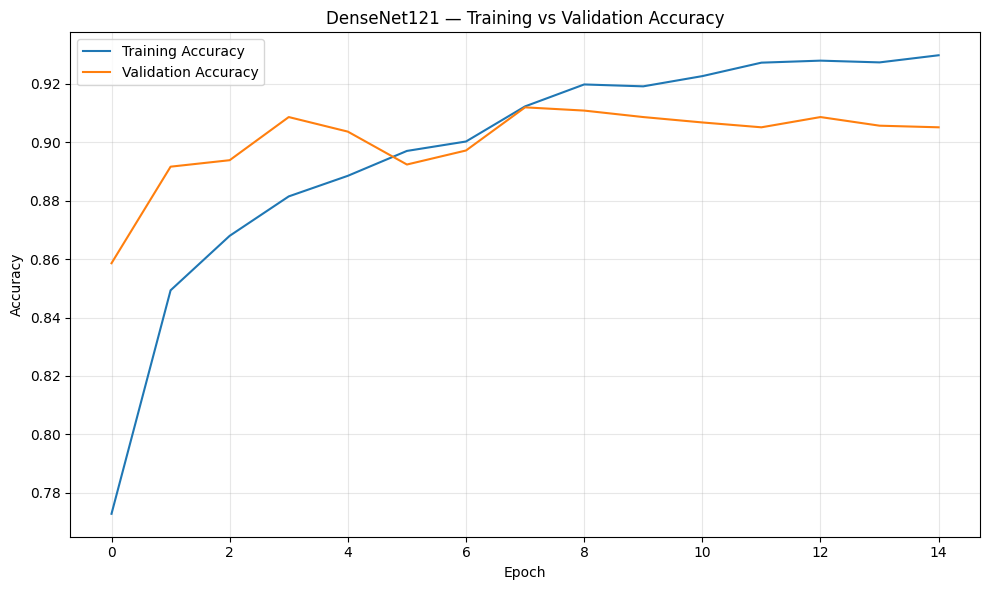

In [23]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 — Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "accuracy_vs_val_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()


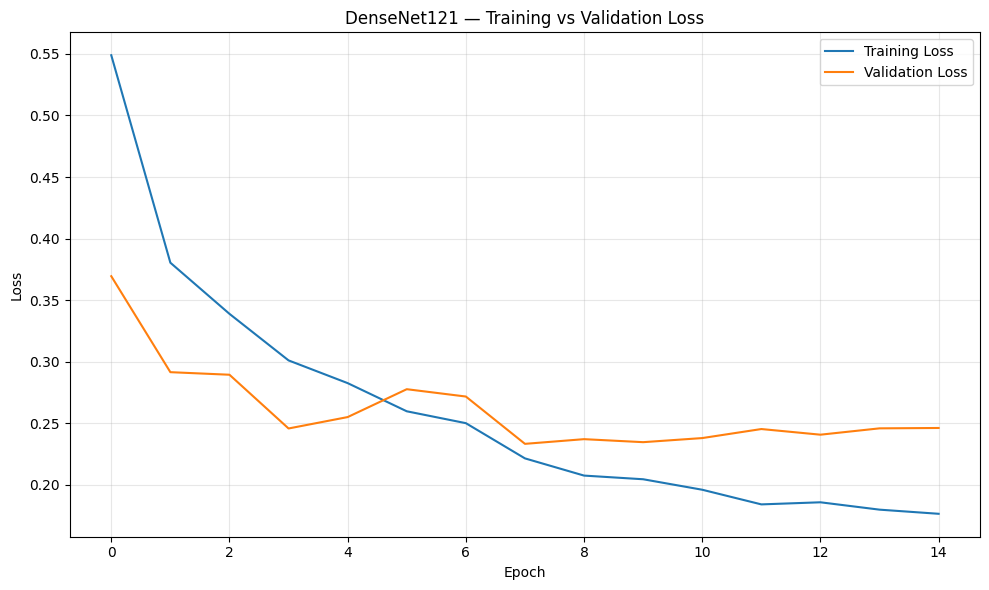

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "loss_vs_val_loss.png", dpi=200, bbox_inches="tight")
plt.show()


In [25]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1,
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")


213/213 ━━━━━━━━━━━━━━━━━━━━ 46s 143ms/step - accuracy: 0.9315 - loss: 0.1954
Test Loss:     0.1954
Test Accuracy: 93.1497%


In [26]:
y_test_batches = []
y_pred_batches = []

for images, labels in test_ds:
    probabilities = best_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    y_test_batches.append(labels.numpy())
    y_pred_batches.append(predictions)

y_test = np.concatenate(y_test_batches)
y_pred = np.concatenate(y_pred_batches)

print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

print("\nFirst 20 true labels:")
print(y_test[:20])

print("\nFirst 20 predicted labels:")
print(y_pred[:20])


y_test shape: (6788,)
y_pred shape: (6788,)

First 20 true labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First 20 predicted labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
test_accuracy_from_predictions = accuracy_score(y_test, y_pred)

best_train_accuracy = max(history.history["accuracy"])
best_val_accuracy = max(history.history["val_accuracy"])
final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

results = {
    "best_train_accuracy": float(best_train_accuracy),
    "best_validation_accuracy": float(best_val_accuracy),
    "final_train_accuracy": float(final_train_accuracy),
    "final_validation_accuracy": float(final_val_accuracy),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_from_y_test_y_pred": float(test_accuracy_from_predictions),
    "test_loss": float(test_loss),
    "epochs_completed": int(len(history.history["loss"])),
}

results_df = pd.DataFrame([results])
display(results_df)

results_df.to_csv(
    REPORT_DIR / "classification_metrics_summary.csv",
    index=False,
)

print("Saved:", REPORT_DIR / "classification_metrics_summary.csv")


,best_train_accuracy,best_validation_accuracy,final_train_accuracy,final_validation_accuracy,test_accuracy,test_accuracy_from_y_test_y_pred,test_loss,epochs_completed
0,0.929772,0.911944,0.929772,0.905114,0.931497,0.931497,0.195367,15


Saved: /content/classification_outputs/reports/classification_metrics_summary.csv


In [28]:
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(report_dict).transpose()

display(classification_report_df)

classification_report_df.to_csv(
    REPORT_DIR / "classification_report.csv"
)

print("Saved:", REPORT_DIR / "classification_report.csv")


,precision,recall,f1-score,support
COVID-19,0.964897,0.941127,0.952864,2395.000000
Non-COVID,0.927960,0.914780,0.921323,2253.000000
Normal,0.900045,0.938318,0.918783,2140.000000
accuracy,0.931497,0.931497,0.931497,0.931497
macro avg,0.930967,0.931408,0.930990,6788.000000
weighted avg,0.932192,0.931497,0.931651,6788.000000


Saved: /content/classification_outputs/reports/classification_report.csv


In [29]:
report_text = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(report_text)

with open(REPORT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", REPORT_DIR / "classification_report.txt")


              precision    recall  f1-score   support

    COVID-19     0.9649    0.9411    0.9529      2395
   Non-COVID     0.9280    0.9148    0.9213      2253
      Normal     0.9000    0.9383    0.9188      2140

    accuracy                         0.9315      6788
   macro avg     0.9310    0.9314    0.9310      6788
weighted avg     0.9322    0.9315    0.9317      6788

Saved: /content/classification_outputs/reports/classification_report.txt


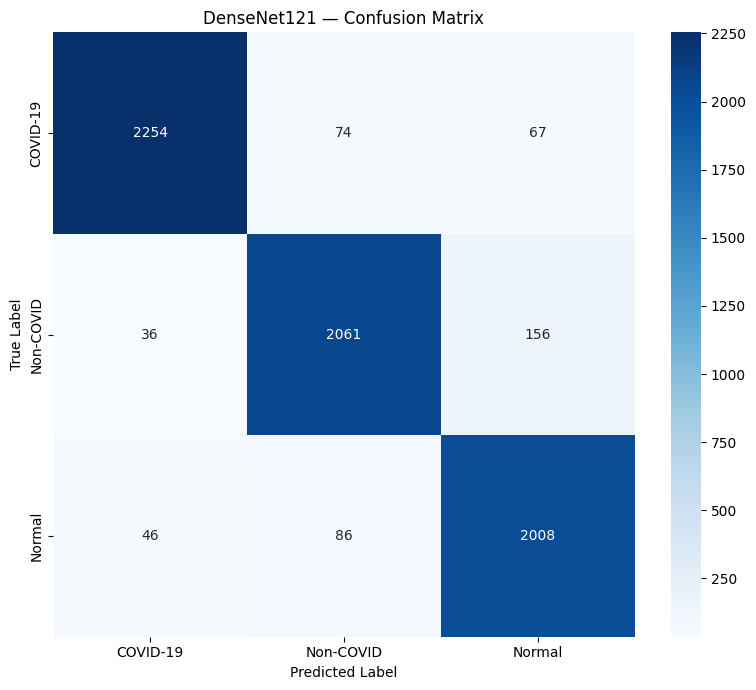

Confusion matrix saved to:
/content/classification_outputs/plots/confusion_matrix.png


In [30]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(NUM_CLASSES),
)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet121 — Confusion Matrix")
plt.tight_layout()

CONFUSION_MATRIX_PATH = PLOT_DIR / "confusion_matrix.png"
plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=250,
    bbox_inches="tight",
)
plt.show()

print("Confusion matrix saved to:")
print(CONFUSION_MATRIX_PATH)


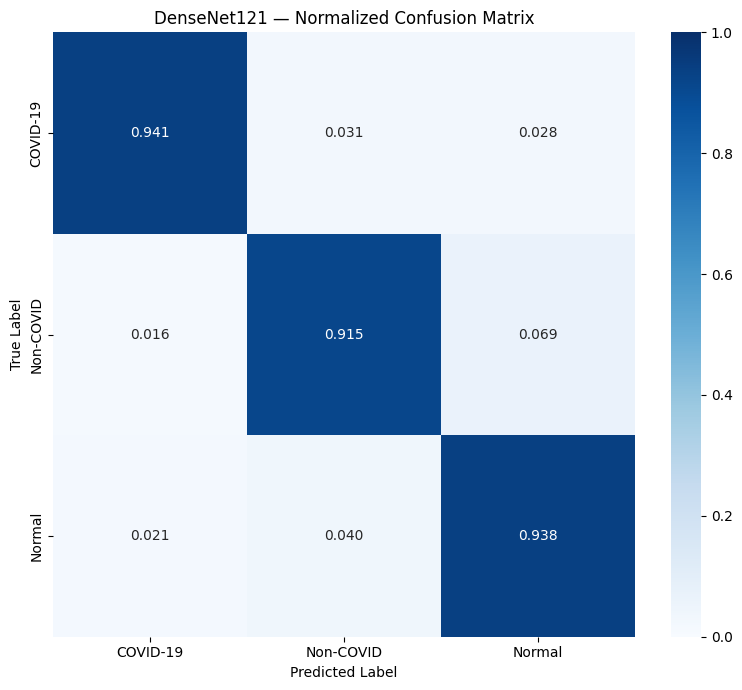

Normalized confusion matrix saved to:
/content/classification_outputs/plots/confusion_matrix_normalized.png


In [31]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    normalize="true",
)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0,
    vmax=1,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet121 — Normalized Confusion Matrix")
plt.tight_layout()

NORMALIZED_CM_PATH = PLOT_DIR / "confusion_matrix_normalized.png"
plt.savefig(
    NORMALIZED_CM_PATH,
    dpi=250,
    bbox_inches="tight",
)
plt.show()

print("Normalized confusion matrix saved to:")
print(NORMALIZED_CM_PATH)


In [32]:
model_metadata = {
    "project": "Medical Image Analysis Assistant",
    "dataset": "COVID-QU-Ex",
    "task": "3-class chest X-ray classification",
    "classes": CLASS_NAMES,
    "architecture": "DenseNet121",
    "pretrained_weights": "ImageNet",
    "input_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "normalization": "image / 255.0",
    "training_augmentation": [
        "RandomFlip(horizontal)",
        "RandomRotation(0.05)",
        "RandomZoom(0.10)",
        "RandomTranslation(0.05)",
        "RandomContrast(0.10)",
    ],
    "fine_tuning": "Last DenseNet121 dense block (conv5_block*) + classification head",
    "optimizer": "AdamW",
    "learning_rate": INITIAL_LR,
    "weight_decay": WEIGHT_DECAY,
    "epochs_requested": EPOCHS,
    "epochs_completed": int(len(history.history["loss"])),
    "seed": SEED,
    "best_train_accuracy": float(best_train_accuracy),
    "best_validation_accuracy": float(best_val_accuracy),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
}

import json

with open(REPORT_DIR / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

print("Saved:", REPORT_DIR / "model_metadata.json")


Saved: /content/classification_outputs/reports/model_metadata.json


In [33]:
FINAL_MODEL_PATH = MODEL_DIR / "densenet121_covidqu_final.keras"

best_model.save(FINAL_MODEL_PATH)

print("Final model saved to:")
print(FINAL_MODEL_PATH)

print("\nBest checkpoint also available at:")
print(BEST_MODEL_PATH)


Final model saved to:
/content/classification_outputs/models/densenet121_covidqu_final.keras

Best checkpoint also available at:
/content/classification_outputs/models/best_densenet121_covidqu.keras


In [34]:
print("Classification output directory contents:\n")

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{path.relative_to(OUTPUT_DIR)}  |  {size_mb:.2f} MB")


Classification output directory contents:

logs/training_log.csv  |  0.00 MB
models/best_densenet121_covidqu.keras  |  44.86 MB
models/densenet121_covidqu_final.keras  |  44.85 MB
plots/accuracy_vs_val_accuracy.png  |  0.10 MB
plots/confusion_matrix.png  |  0.10 MB
plots/confusion_matrix_normalized.png  |  0.10 MB
plots/loss_vs_val_loss.png  |  0.10 MB
plots/training_augmentation_examples.png  |  0.77 MB
reports/classification_metrics_summary.csv  |  0.00 MB
reports/classification_report.csv  |  0.00 MB
reports/classification_report.txt  |  0.00 MB
reports/model_metadata.json  |  0.00 MB


In [35]:
ZIP_BASE = PROJECT_ROOT / "COVIDQU_DenseNet121_results"
ZIP_PATH = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Created:")
print(ZIP_PATH)

print("\nThe ZIP contains:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(OUTPUT_DIR))


Created:
/content/COVIDQU_DenseNet121_results.zip

The ZIP contains:
 - logs/training_log.csv
 - models/best_densenet121_covidqu.keras
 - models/densenet121_covidqu_final.keras
 - plots/accuracy_vs_val_accuracy.png
 - plots/confusion_matrix.png
 - plots/confusion_matrix_normalized.png
 - plots/loss_vs_val_loss.png
 - plots/training_augmentation_examples.png
 - reports/classification_metrics_summary.csv
 - reports/classification_report.csv
 - reports/classification_report.txt
 - reports/model_metadata.json


In [36]:
download_manifest = pd.DataFrame({
    "artifact": [
        "Best DenseNet121 model",
        "Final DenseNet121 model",
        "Classification metrics",
        "Classification report CSV",
        "Classification report TXT",
        "Confusion matrix",
        "Normalized confusion matrix",
        "Accuracy plot",
        "Loss plot",
        "Training log",
        "Complete results ZIP",
    ],
    "path": [
        str(BEST_MODEL_PATH),
        str(FINAL_MODEL_PATH),
        str(REPORT_DIR / "classification_metrics_summary.csv"),
        str(REPORT_DIR / "classification_report.csv"),
        str(REPORT_DIR / "classification_report.txt"),
        str(CONFUSION_MATRIX_PATH),
        str(NORMALIZED_CM_PATH),
        str(PLOT_DIR / "accuracy_vs_val_accuracy.png"),
        str(PLOT_DIR / "loss_vs_val_loss.png"),
        str(CSV_LOG_PATH),
        str(ZIP_PATH),
    ],
})

display(download_manifest)

download_manifest.to_csv(
    REPORT_DIR / "download_manifest.csv",
    index=False,
)

print("Saved:", REPORT_DIR / "download_manifest.csv")


,artifact,path
0,Best DenseNet121 model,/content/classification_outputs/models/best_de...
1,Final DenseNet121 model,/content/classification_outputs/models/densene...
2,Classification metrics,/content/classification_outputs/reports/classi...
3,Classification report CSV,/content/classification_outputs/reports/classi...
4,Classification report TXT,/content/classification_outputs/reports/classi...
5,Confusion matrix,/content/classification_outputs/plots/confusio...
6,Normalized confusion matrix,/content/classification_outputs/plots/confusio...
7,Accuracy plot,/content/classification_outputs/plots/accuracy...
8,Loss plot,/content/classification_outputs/plots/loss_vs_...
9,Training log,/content/classification_outputs/logs/training_...


Saved: /content/classification_outputs/reports/download_manifest.csv


In [37]:
try:
    from google.colab import files

    print("Google Colab detected. Starting ZIP download...")
    files.download(str(ZIP_PATH))

except ImportError:
    from IPython.display import FileLink, display

    print("Local/Jupyter environment detected.")
    print("Use the link below to download the complete results package:")
    display(FileLink(str(ZIP_PATH)))


Google Colab detected. Starting ZIP download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:

print("=" * 70)
print("COVID-QU-Ex — DenseNet121 Classification Final Report")
print("=" * 70)

print(f"Classes: {', '.join(CLASS_NAMES)}")
print(f"Image size: {IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs completed: {len(history.history['loss'])}")

print(f"\nBest Training Accuracy:    {best_train_accuracy:.4%}")
print(f"Best Validation Accuracy:  {best_val_accuracy:.4%}")
print(f"Test Accuracy:             {test_accuracy:.4%}")
print(f"Test Accuracy from y_test/y_pred: {test_accuracy_from_predictions:.4%}")
print(f"Test Loss:                 {test_loss:.4f}")

print("\nBest model:")
print(BEST_MODEL_PATH)

print("\nFinal model:")
print(FINAL_MODEL_PATH)

print("\nResults package:")
print(ZIP_PATH)

print("\nSaved plots:")
print(PLOT_DIR)

print("\nSaved reports:")
print(REPORT_DIR)

print("=" * 70)


COVID-QU-Ex — DenseNet121 Classification Final Report
Classes: COVID-19, Non-COVID, Normal
Image size: (224, 224)
Batch size: 32
Epochs completed: 15

Best Training Accuracy:    92.9772%
Best Validation Accuracy:  91.1944%
Test Accuracy:             93.1497%
Test Accuracy from y_test/y_pred: 93.1497%
Test Loss:                 0.1954

Best model:
/content/classification_outputs/models/best_densenet121_covidqu.keras

Final model:
/content/classification_outputs/models/densenet121_covidqu_final.keras

Results package:
/content/COVIDQU_DenseNet121_results.zip

Saved plots:
/content/classification_outputs/plots

Saved reports:
/content/classification_outputs/reports
